# Step 1 — Image Preprocessing (OpenCV)

Clean a receipt: crop background, greyscale, contrast, threshold to black and white.

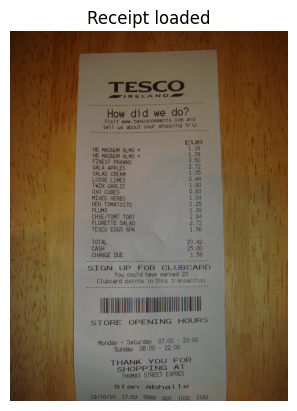

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = "Data/tesco_receipt.png"
img = cv2.imread(IMAGE_PATH)
if img is not None:
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Receipt loaded")
    plt.axis("off")
    plt.show()

In [36]:
def load_image(path):
    """Load image, return RGB."""
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def crop_receipt(img_rgb):
    """Crop to receipt using threshold (white paper vs darker background)."""
    grey = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(grey, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    h, w = img_rgb.shape[:2]
    min_area = h * w * 0.1
    best_rect = None
    best_area = 0
    for c in contours:
        area = cv2.contourArea(c)
        if area < min_area:
            continue
        x, y, rw, rh = cv2.boundingRect(c)
        if rw < 50 or rh < 50:
            continue
        ar = max(rw, rh) / (min(rw, rh) + 1e-6)
        if ar > 15:
            continue
        if area > best_area:
            best_area = area
            best_rect = (x, y, rw, rh)
    if best_rect is None:
        return img_rgb.copy()
    x, y, rw, rh = best_rect
    pad = 10
    return img_rgb[max(0,y-pad):min(h,y+rh+pad), max(0,x-pad):min(w,x+rw+pad)].copy()

def to_greyscale(img_rgb):
    """Convert RGB to greyscale."""
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

def enhance_contrast(grey):
    """Boost contrast with CLAHE."""
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(grey)

def threshold_bw(grey):
    """Binarise to black and white."""
    return cv2.adaptiveThreshold(grey, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

In [37]:
# Pipeline: load → crop → greyscale → contrast → threshold
img_original = load_image(IMAGE_PATH)
img_cropped = crop_receipt(img_original)
grey = to_greyscale(img_cropped)
grey = enhance_contrast(grey)
img_cleaned = threshold_bw(grey)

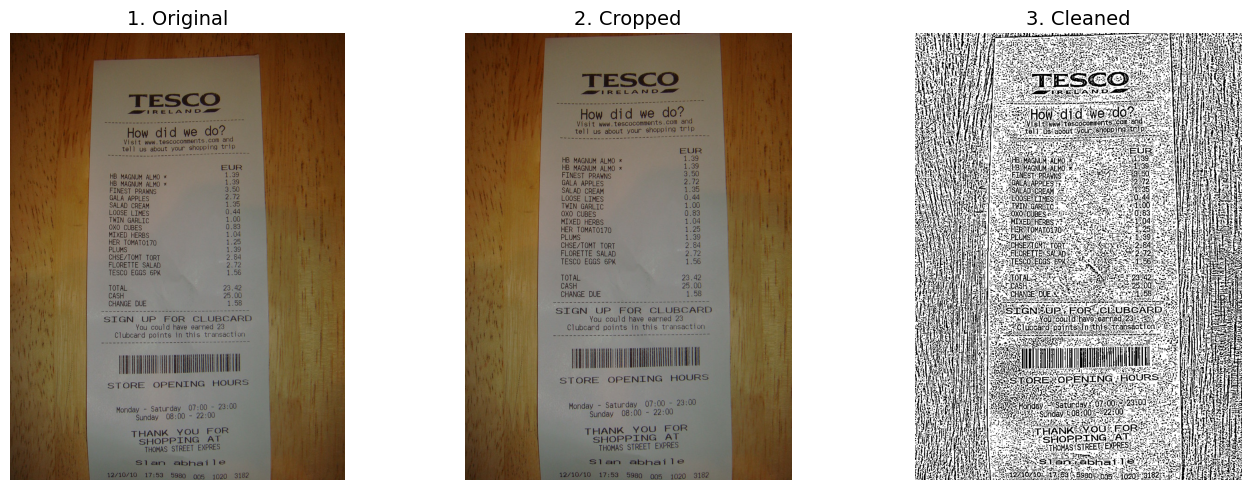

In [38]:
# Before and After
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(img_original)
axes[0].set_title("1. Original", fontsize=14)
axes[0].axis("off")

axes[1].imshow(img_cropped)
axes[1].set_title("2. Cropped", fontsize=14)
axes[1].axis("off")

axes[2].imshow(img_cleaned, cmap="gray")
axes[2].set_title("3. Cleaned", fontsize=14)
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
cv2.imwrite("receipt_cleaned.png", img_cleaned)
